# Plotting the shedding fragmentomics data

## Set up

In [53]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, spearmanr, mannwhitneyu
import matplotlib.gridspec as gridspec
from statannotations.Annotator import Annotator

In [54]:
OUTPUT_DIR = "/SAN/colcc/tracerx_personalis_pipeline/hannah/MRes_Rotation_Hannah/01.personalis/01.shedding/00.fragmentomics"

In [55]:
files = glob.glob(os.path.join(OUTPUT_DIR, "*_per_mut_fragmentomics.tsv"))
print(f"Found {len(files)} files")

Found 14 files


In [56]:
all_mutations = pd.concat([pd.read_csv(f, sep="\t") for f in files])
print(all_mutations.shape)
print(all_mutations.head())

(1932, 19)
    cruk_id tracerx_id            sample  chrom       pos ref alt  \
0  CRUK0080     LTX063  LTX063_5_26_2015  chr10  74101108   G   T   
1  CRUK0080     LTX063  LTX063_5_26_2015  chr11  10803498   T   C   
2  CRUK0080     LTX063  LTX063_5_26_2015  chr11   1256706   G   A   
3  CRUK0080     LTX063  LTX063_5_26_2015  chr11  64318425   C   A   
4  CRUK0080     LTX063  LTX063_5_26_2015  chr11    824292   G   T   

   ccf_z_score ccf_z_score_group  nb_wt  nb_mut  median_frag_length_wt  \
0    -1.105341               low   4615       4                  165.0   
1     0.704948              high   4590       3                  163.0   
2    -0.095126               low   4835       2                  167.0   
3    -2.013316               low   1194       3                  156.0   
4    -0.303560               low   3018       4                  162.0   

   median_frag_length_mut  median_distance_left_wt  median_distance_left_mut  \
0                   153.5                     80.

## Reshape data for plotting

In [57]:
# Reformat for plotting
frag_length_long = pd.melt(
    all_mutations,
    id_vars=["cruk_id", "chrom", "pos", "ref", "alt", "ccf_z_score", "ccf_z_score_group"],
    value_vars=["median_frag_length_wt", "median_frag_length_mut"],
    var_name="fragment_type",
    value_name="median_frag_length"
)

print(frag_length_long.shape)
print(frag_length_long.head())

(3864, 9)
    cruk_id  chrom       pos ref alt  ccf_z_score ccf_z_score_group  \
0  CRUK0080  chr10  74101108   G   T    -1.105341               low   
1  CRUK0080  chr11  10803498   T   C     0.704948              high   
2  CRUK0080  chr11   1256706   G   A    -0.095126               low   
3  CRUK0080  chr11  64318425   C   A    -2.013316               low   
4  CRUK0080  chr11    824292   G   T    -0.303560               low   

           fragment_type  median_frag_length  
0  median_frag_length_wt               165.0  
1  median_frag_length_wt               163.0  
2  median_frag_length_wt               167.0  
3  median_frag_length_wt               156.0  
4  median_frag_length_wt               162.0  


# Deduplication

In [58]:
all_mutations_dedup = all_mutations.groupby(["cruk_id", "chrom", "pos", "ref", "alt"]).agg({
    "median_frag_length_mut":  "median",
    "median_frag_length_wt":   "median",
    "ccf_z_score":             "median",
    "ccf_z_score_group":       "first",
    "median_min_distance_mut": "median",
    "median_min_distance_wt":  "median",
    "nb_mut":                  "median",
    "nb_wt":                   "median"
}).reset_index()

all_mutations_dedup["delta_frag_length"]  = all_mutations_dedup["median_frag_length_mut"]  - all_mutations_dedup["median_frag_length_wt"]
all_mutations_dedup["delta_min_distance"] = all_mutations_dedup["median_min_distance_mut"] - all_mutations_dedup["median_min_distance_wt"]

print(all_mutations_dedup.shape)

(872, 15)


In [59]:
all_mutations_dedup

,cruk_id,chrom,pos,ref,alt,median_frag_length_mut,median_frag_length_wt,ccf_z_score,ccf_z_score_group,median_min_distance_mut,median_min_distance_wt,nb_mut,nb_wt,delta_frag_length,delta_min_distance
0,CRUK0080,chr1,181732775,C,T,136.0,167.0,-0.444027,low,26.0,56.0,5.0,4266.0,-31.0,-30.0
1,CRUK0080,chr10,74101108,G,T,153.5,165.0,-0.752831,low,51.5,55.0,4.0,4615.0,-11.5,-3.5
2,CRUK0080,chr11,824292,G,T,145.5,162.0,-0.201636,low,52.0,50.0,4.0,3018.0,-16.5,2.0
3,CRUK0080,chr11,1256706,G,A,149.0,167.0,0.047801,low,34.0,56.0,2.0,4835.0,-18.0,-22.0
4,CRUK0080,chr11,10803498,T,C,158.0,163.0,0.580093,high,22.0,48.0,3.0,4590.0,-5.0,-26.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
867,CRUK1161,chr8,61499467,G,A,150.0,164.0,-0.787244,low,47.0,40.0,9.0,1899.0,-14.0,7.0
868,CRUK1161,chr8,143984526,T,A,159.0,165.0,-0.266289,high,56.0,51.0,10.0,2183.0,-6.0,5.0
869,CRUK1161,chr9,21971178,C,A,154.0,166.0,-0.142108,low,39.0,49.0,17.0,1696.0,-12.0,-10.0
870,CRUK1161,chr9,115086004,C,G,149.5,166.0,-0.609370,low,52.5,53.0,10.0,1905.0,-16.5,-0.5


## Multi panel figure on deduplicated mutations

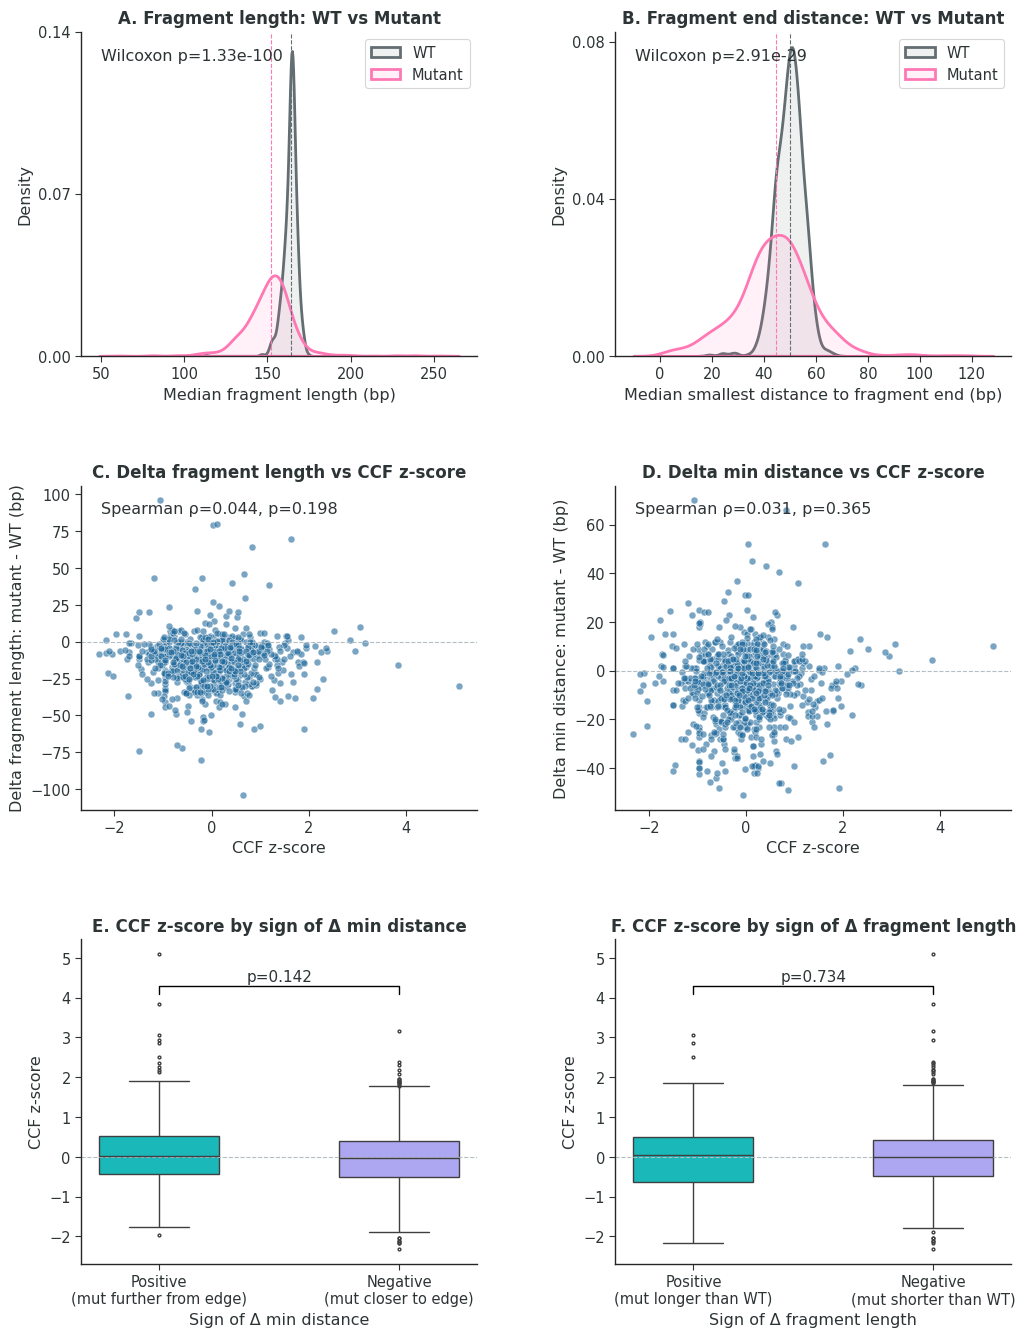

In [60]:
 #---------------------------- Figure setup ----------------------------#

fig = plt.figure(figsize=(12, 16))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])
ax_e = fig.add_subplot(gs[2, 0])
ax_f = fig.add_subplot(gs[2, 1])

# Set style parameters
sns.set_context("paper", font_scale=1.2)
sns.set_style("white")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['text.color'] = '#2D3436'
plt.rcParams['axes.labelcolor'] = '#2D3436'
plt.rcParams['xtick.color'] = '#2D3436'
plt.rcParams['ytick.color'] = '#2D3436'

# Colour scheme
wt_col = "#636E72"       
mut_col = "#FF78B4"      
scatter_col = "#20699C"  
high_col = "#00D2D3"     
low_col = "#A29BFE"     
horiz_line_col = "#B2BEC3"

 #---------------------------- Panel A ----------------------------#

# Wilcoxon signed-rank test (paired per mutation)
stat_a, p_a = wilcoxon(all_mutations_dedup["median_frag_length_wt"].dropna(),
                       all_mutations_dedup["median_frag_length_mut"].dropna())

sns.kdeplot(all_mutations_dedup["median_frag_length_wt"], 
            fill=True, alpha=0.1, color=wt_col, label="WT", ax=ax_a, linewidth=2)
sns.kdeplot(all_mutations_dedup["median_frag_length_mut"], 
            fill=True, alpha=0.1, color=mut_col, label="Mutant", ax=ax_a, linewidth=2)

ax_a.axvline(all_mutations_dedup["median_frag_length_wt"].median(), color=wt_col, linestyle="--", linewidth=0.8)
ax_a.axvline(all_mutations_dedup["median_frag_length_mut"].median(), color=mut_col, linestyle="--", linewidth=0.8)
ax_a.set_xlabel("Median fragment length (bp)")
ax_a.set_ylabel("Density")
y_max_a = ax_a.get_ylim()[1]
ax_a.set_yticks([0, round(y_max_a/2, 2), round(y_max_a, 2)])
ax_a.set_title("A. Fragment length: WT vs Mutant")
ax_a.text(0.05, 0.95, f"Wilcoxon p={p_a:.2e}", transform=ax_a.transAxes, verticalalignment="top")
ax_a.legend()

 #---------------------------- Panel B ----------------------------#

# Wilcoxon signed-rank test (paired per mutation)
stat_b, p_b = wilcoxon(all_mutations_dedup["median_min_distance_wt"].dropna(),
                       all_mutations_dedup["median_min_distance_mut"].dropna())

sns.kdeplot(all_mutations_dedup["median_min_distance_wt"], 
            fill=True, alpha=0.1, color=wt_col, label="WT", ax=ax_b, linewidth=2)
sns.kdeplot(all_mutations_dedup["median_min_distance_mut"], 
            fill=True, alpha=0.1, color=mut_col, label="Mutant", ax=ax_b, linewidth=2)

ax_b.axvline(all_mutations_dedup["median_min_distance_wt"].median(), color=wt_col, linestyle="--", linewidth=0.8)
ax_b.axvline(all_mutations_dedup["median_min_distance_mut"].median(), color=mut_col, linestyle="--", linewidth=0.8)
ax_b.set_xlabel("Median smallest distance to fragment end (bp)")
ax_b.set_ylabel("Density")
y_max_b = ax_b.get_ylim()[1]
ax_b.set_yticks([0, round(y_max_b/2, 2), round(y_max_b, 2)])
ax_b.set_title("B. Fragment end distance: WT vs Mutant")
ax_b.text(0.05, 0.95, f"Wilcoxon p={p_b:.2e}", transform=ax_b.transAxes, verticalalignment="top")
ax_b.legend()

 #---------------------------- Panel C ----------------------------#

# Spearman rho
rho_c, p_c = spearmanr(all_mutations_dedup["ccf_z_score"].dropna(),
                        all_mutations_dedup["delta_frag_length"].dropna())

# Scatter plot
ax_c.scatter(all_mutations_dedup["ccf_z_score"], 
             all_mutations_dedup["delta_frag_length"], 
             alpha=0.6, s=25,
             color=scatter_col, 
             edgecolor='white', linewidth=0.5)

ax_c.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_c.set_xlabel("CCF z-score")
ax_c.set_ylabel("Delta fragment length: mutant - WT (bp)")
ax_c.set_title("C. Delta fragment length vs CCF z-score")
ax_c.text(0.05, 0.95, f"Spearman ρ={rho_c:.3f}, p={p_c:.3f}", 
          transform=ax_c.transAxes, verticalalignment="top")

 #---------------------------- Panel D ----------------------------#

# Spearman rho
rho_d, p_d = spearmanr(all_mutations_dedup["ccf_z_score"].dropna(),
                        all_mutations_dedup["delta_min_distance"].dropna())

# Scatter plot
ax_d.scatter(all_mutations_dedup["ccf_z_score"], 
             all_mutations_dedup["delta_min_distance"], 
             alpha=0.6, s=25,
             color=scatter_col, 
             edgecolor='white', linewidth=0.5)

ax_d.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_d.set_xlabel("CCF z-score")
ax_d.set_ylabel("Delta min distance: mutant - WT (bp)")
ax_d.set_title("D. Delta min distance vs CCF z-score")
ax_d.text(0.05, 0.95, f"Spearman ρ={rho_d:.3f}, p={p_d:.3f}", 
          transform=ax_d.transAxes, verticalalignment="top")


 #---------------------------- Panel E ----------------------------#

# Compute sign of deltas
all_mutations_dedup["delta_min_distance_sign"] = np.where(
    all_mutations_dedup["delta_min_distance"] > 0, "Positive\n(mut further from edge)", 
    "Negative\n(mut closer to edge)"
)
all_mutations_dedup["delta_frag_length_sign"] = np.where(
    all_mutations_dedup["delta_frag_length"] > 0, "Positive\n(mut longer than WT)",
    "Negative\n(mut shorter than WT)"
)

# Mann-Whitney for panel E
pos_e = all_mutations_dedup[all_mutations_dedup["delta_min_distance"] > 0]["ccf_z_score"].dropna()
neg_e = all_mutations_dedup[all_mutations_dedup["delta_min_distance"] < 0]["ccf_z_score"].dropna()
_, p_e = mannwhitneyu(pos_e, neg_e, alternative="greater") # I hypothesise that a positive delta -> higher CCF z-score

# Panel E
sns.boxplot(data=all_mutations_dedup, x="delta_min_distance_sign", y="ccf_z_score",
            order=["Positive\n(mut further from edge)", "Negative\n(mut closer to edge)"],
            palette={"Positive\n(mut further from edge)": high_col, 
                     "Negative\n(mut closer to edge)": low_col},
            hue="delta_min_distance_sign", legend=False,
            ax=ax_e, width=0.5, fliersize=2)
ax_e.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_e.set_xlabel("Sign of Δ min distance")
ax_e.set_ylabel("CCF z-score")
ax_e.set_title("E. CCF z-score by sign of Δ min distance")

# Bracket for panel E
y_e = ax_e.get_ylim()[1] * 0.75
ax_e.plot([0, 0, 1, 1],
          [y_e, y_e + 0.2, y_e + 0.2, y_e], color="black", linewidth=1)
ax_e.text(0.5, y_e + 0.25, f"p={p_e:.3f}", ha="center", va="bottom", fontsize=11)


 #---------------------------- Panel F ----------------------------#

# Mann-Whitney for panel F
pos_f = all_mutations_dedup[all_mutations_dedup["delta_frag_length"] > 0]["ccf_z_score"].dropna()
neg_f = all_mutations_dedup[all_mutations_dedup["delta_frag_length"] < 0]["ccf_z_score"].dropna()
_, p_f = mannwhitneyu(pos_f, neg_f, alternative="two-sided")

# Panel F
sns.boxplot(data=all_mutations_dedup, x="delta_frag_length_sign", y="ccf_z_score",
            order=["Positive\n(mut longer than WT)", "Negative\n(mut shorter than WT)"],
            palette={"Positive\n(mut longer than WT)": high_col,
                     "Negative\n(mut shorter than WT)": low_col},
            hue="delta_frag_length_sign", legend=False,
            ax=ax_f, width=0.5, fliersize=2)
ax_f.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_f.set_xlabel("Sign of Δ fragment length")
ax_f.set_ylabel("CCF z-score")
ax_f.set_title("F. CCF z-score by sign of Δ fragment length")

# Bracket for panel F
y_f = ax_f.get_ylim()[1] * 0.75
ax_f.plot([0, 0, 1, 1],
          [y_f, y_f + 0.2, y_f + 0.2, y_f], color="black", linewidth=1)
ax_f.text(0.5, y_f + 0.25, f"p={p_f:.3f}", ha="center", va="bottom", fontsize=11)


 #---------------------------- Final plot ----------------------------#

for ax in [ax_a, ax_b, ax_c, ax_d, ax_e, ax_f]:
    sns.despine(ax=ax)
    ax.tick_params(axis='both', which='both', length=4, width=0.8, 
                   bottom=True, left=True, color='#2D3436')
    ax.title.set_weight('bold')
    ax.title.set_fontsize(12)

plt.show()

In [71]:
import os
print(os.getcwd())

/SAN/colcc/tracerx_personalis_pipeline/hannah/MRes_Rotation_Hannah/01.personalis/01.shedding


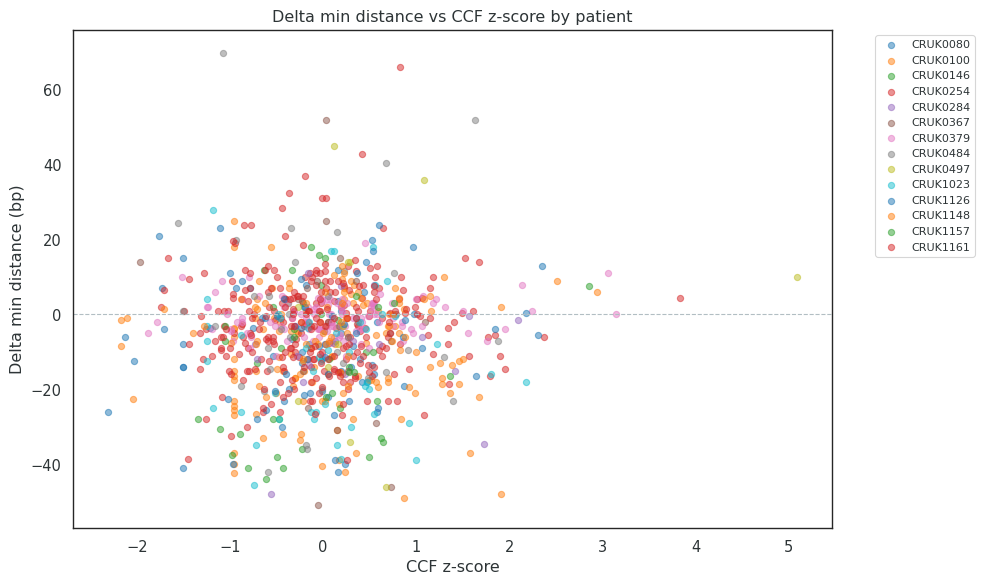

In [61]:
fig_qc, ax_qc = plt.subplots(figsize=(10, 6))

for patient in all_mutations_dedup["cruk_id"].unique():
    subset = all_mutations_dedup[all_mutations_dedup["cruk_id"] == patient]
    ax_qc.scatter(subset["ccf_z_score"], subset["delta_min_distance"],
                  alpha=0.5, s=20, label=patient)

ax_qc.axhline(0, color=horiz_line_col, linestyle="--", linewidth=0.8)
ax_qc.set_xlabel("CCF z-score")
ax_qc.set_ylabel("Delta min distance (bp)")
ax_qc.set_title("Delta min distance vs CCF z-score by patient")
ax_qc.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Fragment lengths

In [62]:
frag_length_long = pd.melt(
    all_mutations_dedup,
    id_vars=["cruk_id", "chrom", "pos", "ref", "alt", "ccf_z_score", "ccf_z_score_group"],
    value_vars=["median_frag_length_wt", "median_frag_length_mut"],
    var_name="fragment_type",
    value_name="median_frag_length"
)

# Clean up fragment_type labels
frag_length_long["fragment_type"] = frag_length_long["fragment_type"].map({
    "median_frag_length_wt": "WT",
    "median_frag_length_mut": "Mutant"
})

print(frag_length_long.shape)
print(frag_length_long["fragment_type"].value_counts())

(1744, 9)
fragment_type
WT        872
Mutant    872
Name: count, dtype: int64


In [63]:
frag_length_long

,cruk_id,chrom,pos,ref,alt,ccf_z_score,ccf_z_score_group,fragment_type,median_frag_length
0,CRUK0080,chr1,181732775,C,T,-0.444027,low,WT,167.0
1,CRUK0080,chr10,74101108,G,T,-0.752831,low,WT,165.0
2,CRUK0080,chr11,824292,G,T,-0.201636,low,WT,162.0
3,CRUK0080,chr11,1256706,G,A,0.047801,low,WT,167.0
4,CRUK0080,chr11,10803498,T,C,0.580093,high,WT,163.0
...,...,...,...,...,...,...,...,...,...
1739,CRUK1161,chr8,61499467,G,A,-0.787244,low,Mutant,150.0
1740,CRUK1161,chr8,143984526,T,A,-0.266289,high,Mutant,159.0
1741,CRUK1161,chr9,21971178,C,A,-0.142108,low,Mutant,154.0
1742,CRUK1161,chr9,115086004,C,G,-0.609370,low,Mutant,149.5


In [64]:
frag_length_long["group"] = frag_length_long["ccf_z_score_group"] + " " + frag_length_long["fragment_type"]
print(frag_length_long["group"].value_counts())

group
low WT         450
low Mutant     450
high WT        422
high Mutant    422
Name: count, dtype: int64


In [65]:
frag_length_long

,cruk_id,chrom,pos,ref,alt,ccf_z_score,ccf_z_score_group,fragment_type,median_frag_length,group
0,CRUK0080,chr1,181732775,C,T,-0.444027,low,WT,167.0,low WT
1,CRUK0080,chr10,74101108,G,T,-0.752831,low,WT,165.0,low WT
2,CRUK0080,chr11,824292,G,T,-0.201636,low,WT,162.0,low WT
3,CRUK0080,chr11,1256706,G,A,0.047801,low,WT,167.0,low WT
4,CRUK0080,chr11,10803498,T,C,0.580093,high,WT,163.0,high WT
...,...,...,...,...,...,...,...,...,...,...
1739,CRUK1161,chr8,61499467,G,A,-0.787244,low,Mutant,150.0,low Mutant
1740,CRUK1161,chr8,143984526,T,A,-0.266289,high,Mutant,159.0,high Mutant
1741,CRUK1161,chr9,21971178,C,A,-0.142108,low,Mutant,154.0,low Mutant
1742,CRUK1161,chr9,115086004,C,G,-0.609370,low,Mutant,149.5,low Mutant


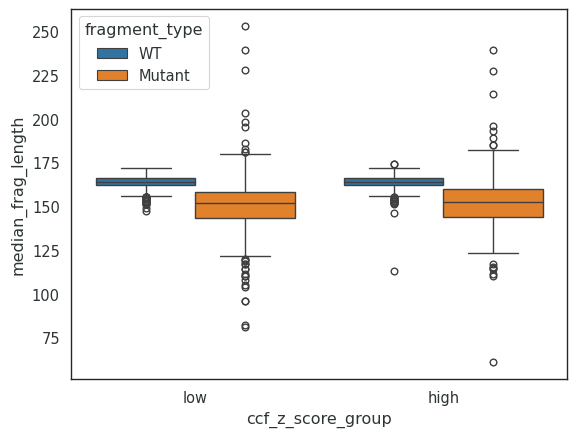

In [66]:
sns.boxplot(
    data=frag_length_long,
    x="ccf_z_score_group",
    y="median_frag_length",
    hue="fragment_type"
)
plt.show()

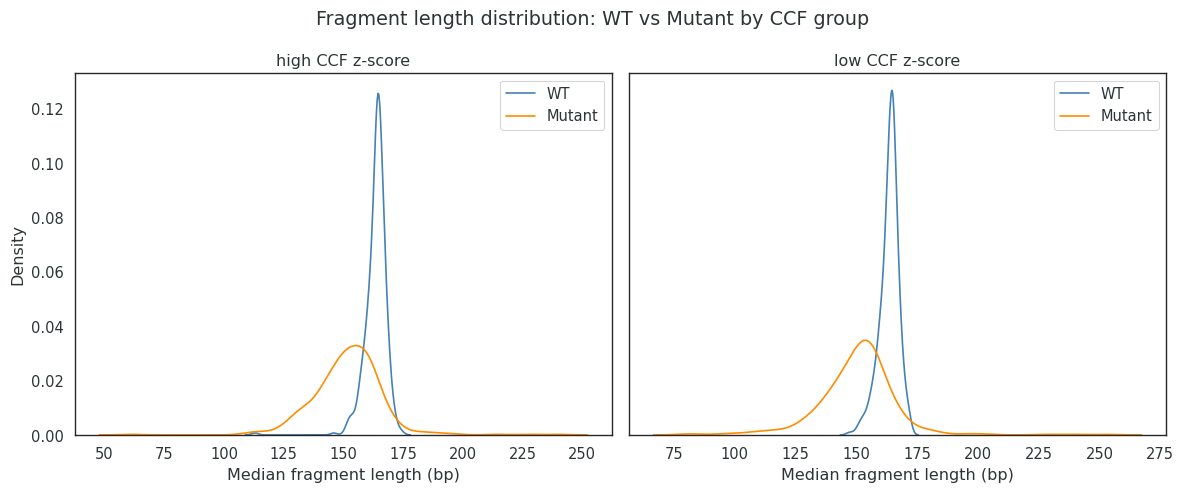

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, group in zip(axes, ["high", "low"]):
    for ftype, color in zip(["WT", "Mutant"], ["steelblue", "darkorange"]):
        subset = frag_length_long[
            (frag_length_long["ccf_z_score_group"] == group) &
            (frag_length_long["fragment_type"] == ftype)
        ]
        sns.kdeplot(subset["median_frag_length"], label=ftype, color=color, ax=ax)
    ax.set_title(f"{group} CCF z-score")
    ax.set_xlabel("Median fragment length (bp)")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Fragment length distribution: WT vs Mutant by CCF group")
plt.tight_layout()
plt.show()

In [68]:
# Compute difference between differences in fragment length
all_mutations_dedup["delta_frag_length"] = all_mutations_dedup["median_frag_length_mut"] - all_mutations_dedup["median_frag_length_wt"]

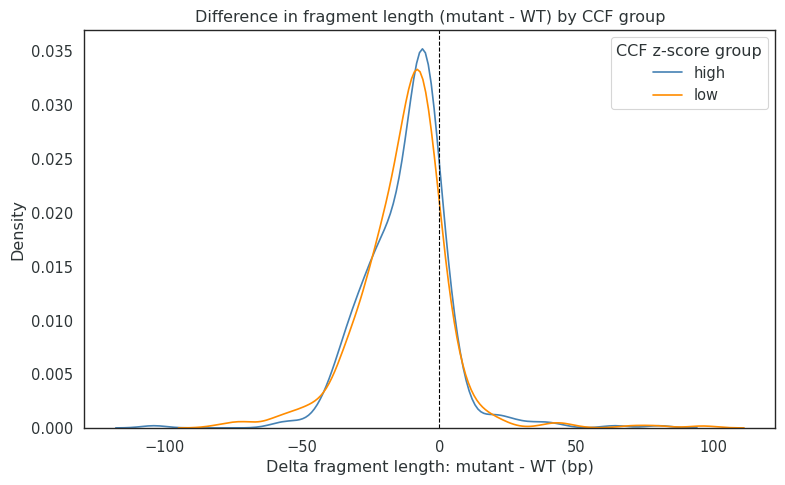

In [69]:
fig, ax = plt.subplots(figsize=(8, 5))

for group, color in zip(["high", "low"], ["steelblue", "darkorange"]):
    subset = all_mutations_dedup[all_mutations_dedup["ccf_z_score_group"] == group]
    sns.kdeplot(subset["delta_frag_length"], label=group, color=color, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Delta fragment length: mutant - WT (bp)")
ax.set_ylabel("Density")
ax.set_title("Difference in fragment length (mutant - WT) by CCF group")
ax.legend(title="CCF z-score group")
plt.tight_layout()
plt.show()

In [72]:
# Continuous correlation (Spearman)
spearmanr(all_mutations_dedup["ccf_z_score"].dropna(), all_mutations_dedup["delta_frag_length"].dropna())

SignificanceResult(statistic=0.043663646981759174, pvalue=0.19769831594208648)

## Distances

In [73]:
all_mutations_dedup["delta_min_distance"] = all_mutations_dedup["median_min_distance_mut"] - all_mutations_dedup["median_min_distance_wt"]

In [74]:
spearmanr(all_mutations_dedup["ccf_z_score"].dropna(), all_mutations_dedup["delta_min_distance"].dropna())

SignificanceResult(statistic=0.030694244742277145, pvalue=0.3653047082671451)

In [75]:
print(all_mutations_dedup["delta_min_distance"].describe())
print(all_mutations_dedup["delta_min_distance"].median())

count    872.000000
mean      -5.571101
std       14.717492
min      -51.000000
25%      -14.000000
50%       -4.000000
75%        3.000000
max       70.000000
Name: delta_min_distance, dtype: float64
-4.0


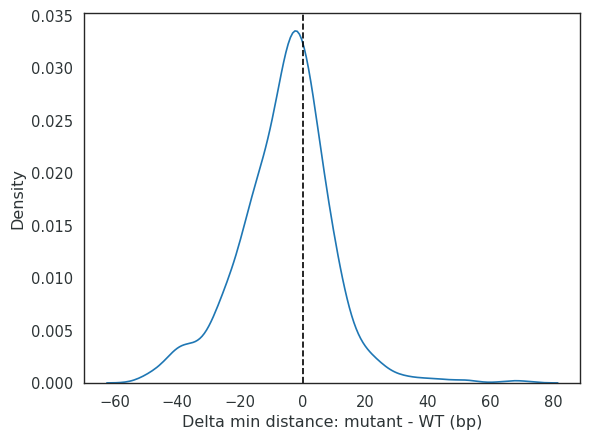

In [76]:
sns.kdeplot(all_mutations_dedup["delta_min_distance"].dropna())
plt.axvline(0, color="black", linestyle="--")
plt.xlabel("Delta min distance: mutant - WT (bp)")
plt.show()

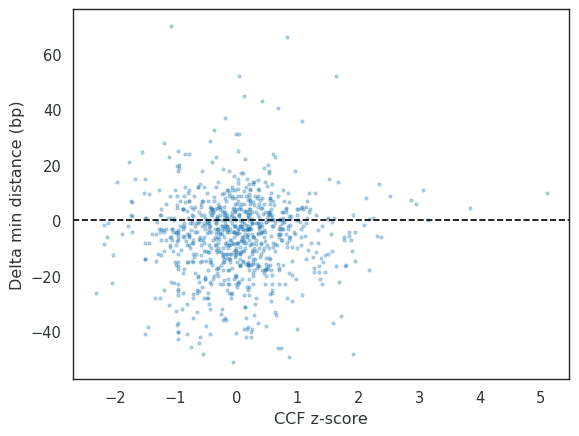

In [77]:
plt.scatter(all_mutations_dedup["ccf_z_score"], all_mutations_dedup["delta_min_distance"], alpha=0.3, s=5)
plt.xlabel("CCF z-score")
plt.ylabel("Delta min distance (bp)")
plt.axhline(0, color="black", linestyle="--")
plt.show()

# Without deduplication (this is not best practice)

In [78]:
# Compute deltas
all_mutations["delta_frag_length"] = all_mutations["median_frag_length_mut"] - all_mutations["median_frag_length_wt"]
all_mutations["delta_min_distance"] = all_mutations["median_min_distance_mut"] - all_mutations["median_min_distance_wt"]

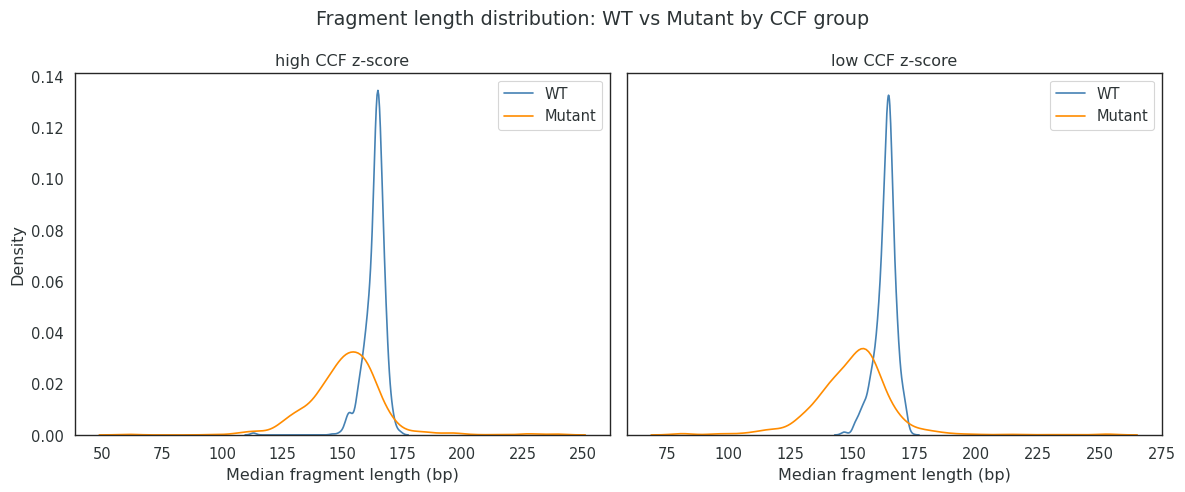

In [79]:
# Fragment length KDE by CCF group
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

frag_length_long = pd.melt(
    all_mutations,
    id_vars=["cruk_id", "sample", "chrom", "pos", "ref", "alt", "ccf_z_score", "ccf_z_score_group"],
    value_vars=["median_frag_length_wt", "median_frag_length_mut"],
    var_name="fragment_type",
    value_name="median_frag_length"
)
frag_length_long["fragment_type"] = frag_length_long["fragment_type"].map({
    "median_frag_length_wt": "WT",
    "median_frag_length_mut": "Mutant"
})

for ax, group in zip(axes, ["high", "low"]):
    for ftype, color in zip(["WT", "Mutant"], ["steelblue", "darkorange"]):
        subset = frag_length_long[
            (frag_length_long["ccf_z_score_group"] == group) &
            (frag_length_long["fragment_type"] == ftype)
        ]
        sns.kdeplot(subset["median_frag_length"], label=ftype, color=color, ax=ax)
    ax.set_title(f"{group} CCF z-score")
    ax.set_xlabel("Median fragment length (bp)")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("Fragment length distribution: WT vs Mutant by CCF group")
plt.tight_layout()
plt.show()

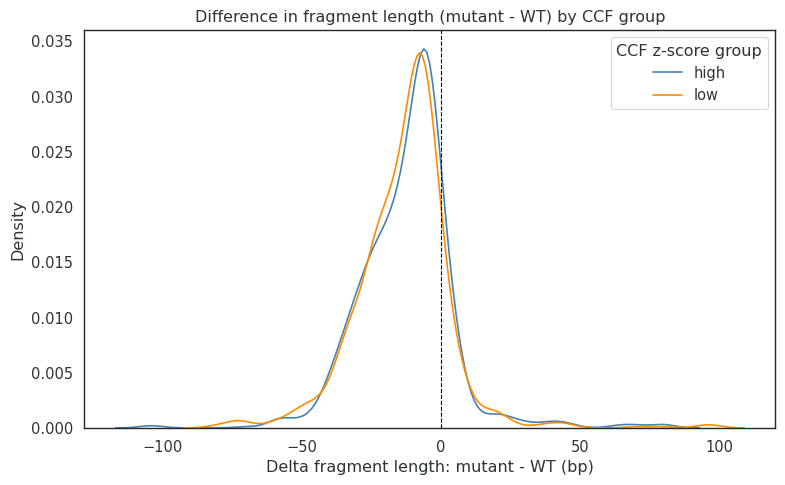

Mann-Whitney U: stat=488228.5, p=0.0728
Median delta high: -10.00 bp
Median delta low: -11.00 bp
SignificanceResult(statistic=0.02176210994400314, pvalue=0.33905339697976555)


In [80]:
# Delta fragment length KDE and stats
fig, ax = plt.subplots(figsize=(8, 5))

for group, color in zip(["high", "low"], ["steelblue", "darkorange"]):
    subset = all_mutations[all_mutations["ccf_z_score_group"] == group]
    sns.kdeplot(subset["delta_frag_length"], label=group, color=color, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Delta fragment length: mutant - WT (bp)")
ax.set_ylabel("Density")
ax.set_title("Difference in fragment length (mutant - WT) by CCF group")
ax.legend(title="CCF z-score group")
plt.tight_layout()
plt.show()

high_delta = all_mutations[all_mutations["ccf_z_score_group"] == "high"]["delta_frag_length"].dropna()
low_delta  = all_mutations[all_mutations["ccf_z_score_group"] == "low"]["delta_frag_length"].dropna()
stat, p = mannwhitneyu(high_delta, low_delta, alternative="two-sided")
print(f"Mann-Whitney U: stat={stat:.1f}, p={p:.4f}")
print(f"Median delta high: {high_delta.median():.2f} bp")
print(f"Median delta low: {low_delta.median():.2f} bp")
print(spearmanr(all_mutations["ccf_z_score"].dropna(), all_mutations["delta_frag_length"].dropna()))

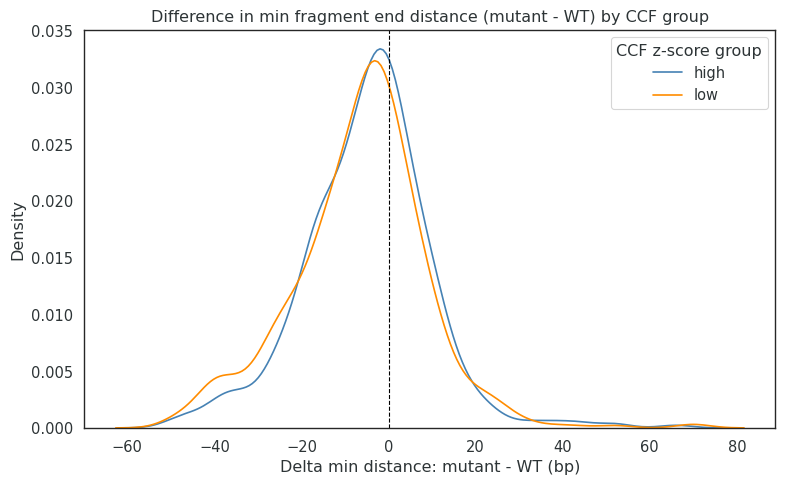

count    1932.000000
mean       -5.781832
std        15.020438
min       -51.000000
25%       -14.500000
50%        -4.500000
75%         3.000000
max        70.000000
Name: delta_min_distance, dtype: float64
SignificanceResult(statistic=0.032988729320973624, pvalue=0.14720919487169115)


In [81]:
# Delta min distance KDE and stats
fig, ax = plt.subplots(figsize=(8, 5))

for group, color in zip(["high", "low"], ["steelblue", "darkorange"]):
    subset = all_mutations[all_mutations["ccf_z_score_group"] == group]
    sns.kdeplot(subset["delta_min_distance"], label=group, color=color, ax=ax)

ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Delta min distance: mutant - WT (bp)")
ax.set_ylabel("Density")
ax.set_title("Difference in min fragment end distance (mutant - WT) by CCF group")
ax.legend(title="CCF z-score group")
plt.tight_layout()
plt.show()

print(all_mutations["delta_min_distance"].describe())
print(spearmanr(all_mutations["ccf_z_score"].dropna(), all_mutations["delta_min_distance"].dropna()))

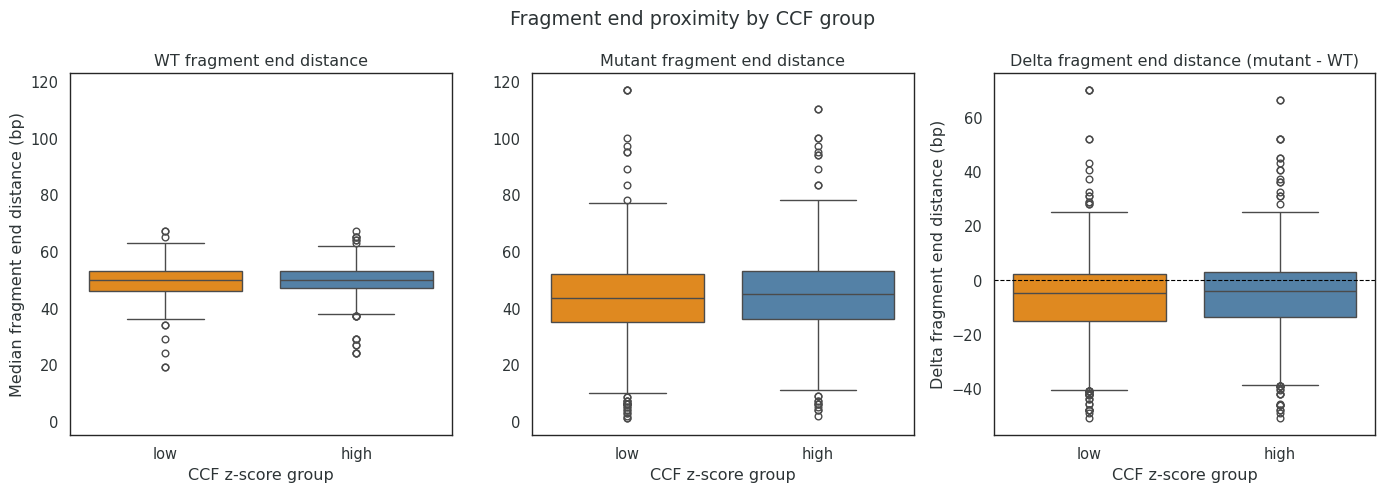

In [82]:
# Fragment end proximity boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

sns.boxplot(data=all_mutations, x="ccf_z_score_group", y="median_min_distance_wt",
            order=["low", "high"], hue="ccf_z_score_group", hue_order=["low", "high"],
            palette=["darkorange", "steelblue"], legend=False, ax=axes[0])
axes[0].set_title("WT fragment end distance")
axes[0].set_xlabel("CCF z-score group")
axes[0].set_ylabel("Median fragment end distance (bp)")

sns.boxplot(data=all_mutations, x="ccf_z_score_group", y="median_min_distance_mut",
            order=["low", "high"], hue="ccf_z_score_group", hue_order=["low", "high"],
            palette=["darkorange", "steelblue"], legend=False, ax=axes[1])
axes[1].set_title("Mutant fragment end distance")
axes[1].set_xlabel("CCF z-score group")
axes[1].set_ylabel("")

sns.boxplot(data=all_mutations, x="ccf_z_score_group", y="delta_min_distance",
            order=["low", "high"], hue="ccf_z_score_group", hue_order=["low", "high"],
            palette=["darkorange", "steelblue"], legend=False, ax=axes[2])
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Delta fragment end distance (mutant - WT)")
axes[2].set_xlabel("CCF z-score group")
axes[2].set_ylabel("Delta fragment end distance (bp)")

# Share y axis between first two panels
ymin = min(axes[0].get_ylim()[0], axes[1].get_ylim()[0])
ymax = max(axes[0].get_ylim()[1], axes[1].get_ylim()[1])
axes[0].set_ylim(ymin, ymax)
axes[1].set_ylim(ymin, ymax)

plt.suptitle("Fragment end proximity by CCF group")
plt.tight_layout()
plt.show()

/tmp/ipykernel_63111/1290104699.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


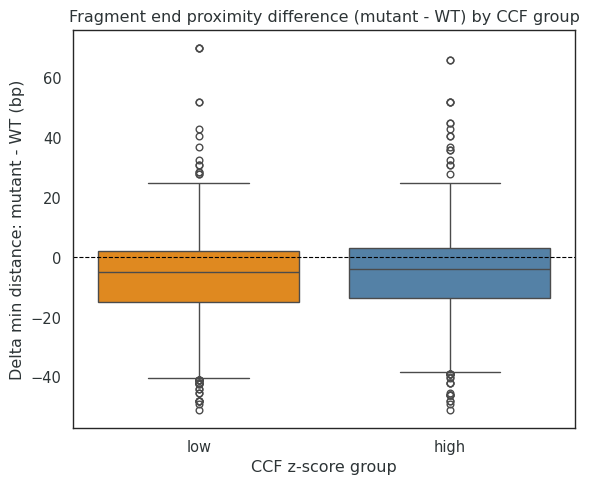

In [83]:
# Box plot showing delta min distance by CCF group
fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(
    data=all_mutations,
    x="ccf_z_score_group",
    y="delta_min_distance",
    order=["low", "high"],
    palette=["darkorange", "steelblue"],
    ax=ax
)

ax.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("CCF z-score group")
ax.set_ylabel("Delta min distance: mutant - WT (bp)")
ax.set_title("Fragment end proximity difference (mutant - WT) by CCF group")
plt.tight_layout()
plt.show()

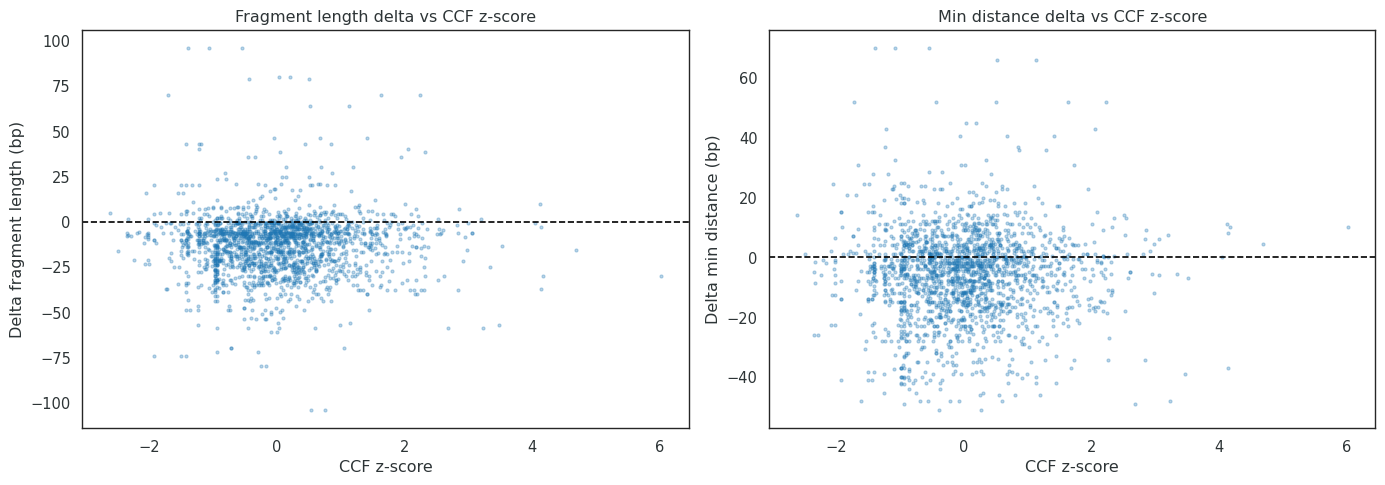

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(all_mutations["ccf_z_score"], all_mutations["delta_frag_length"], alpha=0.3, s=5)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_xlabel("CCF z-score")
axes[0].set_ylabel("Delta fragment length (bp)")
axes[0].set_title("Fragment length delta vs CCF z-score")

axes[1].scatter(all_mutations["ccf_z_score"], all_mutations["delta_min_distance"], alpha=0.3, s=5)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("CCF z-score")
axes[1].set_ylabel("Delta min distance (bp)")
axes[1].set_title("Min distance delta vs CCF z-score")

plt.tight_layout()
plt.show()

# Data counts for report

In [85]:
# Fragment counts summary
print("=== Mutant fragment counts ===")
print(all_mutations_dedup["nb_mut"].describe())

print("\n=== WT fragment counts ===")
print(all_mutations_dedup["nb_wt"].describe())

print("\n=== Fragment length summary ===")
print("Median WT fragment length:", all_mutations_dedup["median_frag_length_wt"].median())
print("Median mutant fragment length:", all_mutations_dedup["median_frag_length_mut"].median())
print("Median delta fragment length:", all_mutations_dedup["delta_frag_length"].median())

print("\n=== Min distance summary ===")
print("Median WT min distance:", all_mutations_dedup["median_min_distance_wt"].median())
print("Median mutant min distance:", all_mutations_dedup["median_min_distance_mut"].median())
print("Median delta min distance:", all_mutations_dedup["delta_min_distance"].median())

print("\n=== Sign of delta min distance ===")
print(all_mutations_dedup["delta_min_distance_sign"].value_counts())

print("\n=== Mutations per patient ===")
print(all_mutations_dedup.groupby("cruk_id").size().describe())

print("\n=== CCF z-score group counts ===")
print(all_mutations_dedup["ccf_z_score_group"].value_counts())

=== Mutant fragment counts ===
count     872.000000
mean       51.809633
std       121.198324
min         1.000000
25%         3.750000
50%         8.000000
75%        17.000000
max      1608.000000
Name: nb_mut, dtype: float64

=== WT fragment counts ===
count     872.000000
mean     2748.569954
std      1016.110080
min       354.000000
25%      2070.000000
50%      2579.000000
75%      3353.250000
max      6932.000000
Name: nb_wt, dtype: float64

=== Fragment length summary ===
Median WT fragment length: 164.0
Median mutant fragment length: 152.0
Median delta fragment length: -10.0

=== Min distance summary ===
Median WT min distance: 50.0
Median mutant min distance: 44.5
Median delta min distance: -4.0

=== Sign of delta min distance ===
delta_min_distance_sign
Negative\n(mut closer to edge)       586
Positive\n(mut further from edge)    286
Name: count, dtype: int64

=== Mutations per patient ===
count     14.000000
mean      62.285714
std       51.892535
min       12.000000
25%   